# **Fase 4c: Fusión Temporal Multiclase, Grid Search y Comparativa FPS (Inferencia CNN)**

**Autor:** Andoni Cabrera Fernández

**Descripción Técnica:**
Este cuaderno constituye el núcleo de decisión lógica de la Fase 4. Carga las predicciones probabilísticas (*logits*) serializadas (`prob_ojo_cerrado` y `prob_bostezo`) emitidas por los modelos TFLite en la extracción offline (Fase 4b) y aplica una estrategia de **Fusión Tardía (*Late Fusion*)**.

En lugar de delegar la decisión final a una red densa o un perceptrón multicapa, se implementan reglas fisiológicas basadas en la escala clínica KSS:
1. Métrica **PERCLOS** (Porcentaje de Cierre Ocular) para alertar de somnolencia crítica (Clase 10).
2. **Filtro de Racha Temporal** para identificar bostezos genuinos y diagnosticar baja vigilancia (Clase 5).

Mediante un algoritmo de **Búsqueda en Malla (*Grid Search 4D*)** exhaustivo, se determina qué combinación de ventana PERCLOS, umbral de activación y tiempo de bostezo sostenido maximiza el F1-Score, evaluando simultáneamente el impacto de la resolución temporal a **30, 15, 5 y 1 FPS** para justificar la viabilidad del paradigma TinyML.

## 1. IMPORTACIÓN E INFRAESTRUCTURA

In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# 1. Montar Google Drive
drive.mount('/content/drive')

# =========================================================================
# CONFIGURACIÓN DEL ENTORNO Y CARGA DE DATOS MULTI-FPS
# =========================================================================
# Ruta corregida según tu indicación: TFG_Fatiga_Colab
ruta_base = '/content/drive/MyDrive/TFG_Fatiga_Colab/PKL_CNN'

print("Iniciando carga de archivos de telemetría convolucional...")
espacio_fps = [30, 15, 5, 1]
datos_dict = {}

for fps in espacio_fps:
    # Ajustamos el nombre para que coincida exactamente con tu captura: datos_TFLITE_Xfps.pkl
    nombre_archivo = f'datos_TFLITE_{fps}fps.pkl'
    ruta_completa = os.path.join(ruta_base, nombre_archivo)

    if os.path.exists(ruta_completa):
        with open(ruta_completa, 'rb') as f:
            df = pickle.load(f)
            if isinstance(df, list):
                df = pd.DataFrame(df)
            datos_dict[fps] = df
        print(f" Cargado con éxito: {nombre_archivo} ({len(df)} registros procesados)")
    else:
        print(f" No se encontró el archivo {nombre_archivo} en {ruta_base}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando carga de archivos de telemetría convolucional...
 Cargado con éxito: datos_TFLITE_30fps.pkl (3043585 registros procesados)
 Cargado con éxito: datos_TFLITE_15fps.pkl (1521826 registros procesados)
 Cargado con éxito: datos_TFLITE_5fps.pkl (507333 registros procesados)
 Cargado con éxito: datos_TFLITE_1fps.pkl (101538 registros procesados)


## 2. METODOLOGÍA DE DIAGNÓSTICO (MOTOR LÓGICO-TEMPORAL)



In [2]:
def evaluar_video_cnn(df_video, fps, w_perclos, p_th, b_sec, prob_ojo_th=0.5, prob_boca_th=0.5):
    """
    Simula el motor de inferencia lógico-temporal para un único flujo de vídeo
    evaluando las salidas probabilísticas de las redes MobileNetV2.
    """
    df_video = df_video.sort_values('frame_idx').copy()

    # 1. Conversión de variables de tiempo a equivalencia en fotogramas
    frames_perclos = max(1, int(w_perclos * fps))
    frames_bostezo = max(1, int(b_sec * fps))

    # 2. Binarización de los logits de las redes expertas cuantizadas
    df_video['ojo_cerrado'] = (df_video['prob_ojo_cerrado'] > prob_ojo_th).astype(int)
    df_video['boca_abierta'] = (df_video['prob_bostezo'] > prob_boca_th).astype(int)

    # 3. Cálculo del estándar PERCLOS mediante ventana móvil rolling
    df_video['perclos_rolling'] = df_video['ojo_cerrado'].rolling(window=frames_perclos, min_periods=1).mean()

    # 4. Cálculo del filtro de racha maxilar (paso bajo) para aislar el habla
    df_video['racha_bostezo'] = df_video['boca_abierta'].rolling(window=frames_bostezo, min_periods=1).sum()

    # =====================================================================
    # 5. MÁQUINA DE ESTADOS FINITOS MULTICLASE (JERARQUÍA CLÍNICA)
    # =====================================================================
    # Criterio 1: Somnolencia Crítica e Inminencia de Microsueño (Clase 10)
    if (df_video['perclos_rolling'] > p_th).any():
        return 10

    # Criterio 2: Estado de Baja Vigilancia por Fatiga Transitoria (Clase 5)
    if (df_video['racha_bostezo'] >= frames_bostezo).any():
        return 5

    # Criterio 3: Conducción en Estado Basal de Alerta (Clase 0)
    return 0

def evaluar_dataset_completo(df, fps, w_perclos, p_th, b_sec):
    """
    Recorre el conjunto de datos completo evaluando de forma aislada cada vídeo.
    """
    y_true = []
    y_pred = []

    lista_videos = df['video'].unique()
    for vid in lista_videos:
        df_vid = df[df['video'] == vid]
        clase_real = df_vid['clase_real'].iloc[0]

        prediccion = evaluar_video_cnn(df_vid, fps, w_perclos, p_th, b_sec)

        y_true.append(clase_real)
        y_pred.append(prediccion)

    return y_true, y_pred

## 3. OPTIMIZACIÓN DE HIPERPARÁMETROS (GRID SEARCH 4D MULTICLASE)

In [3]:
# =========================================================================
# CONFIGURACIÓN DEL ESPACIO DE BÚSQUEDA EN CUADRÍCULA
# =========================================================================
espacio_w_perclos = [30, 60, 90]               # Ventanas de integración temporal (segundos)
espacio_p_th = [0.05, 0.10, 0.15, 0.20, 0.25]  # Umbrales críticos de PERCLOS
espacio_b_sec = [1.0, 1.5, 2.0]                # Duración mínima del bostezo sostenido (segundos)

resultados_grid = []
fps_disponibles = [f for f in espacio_fps if f in datos_dict]

if not fps_disponibles:
    raise KeyError("No se ha cargado ninguna matriz de datos en memoria. Verifica las rutas en la Celda 3.")

total_iteraciones = len(fps_disponibles) * len(espacio_w_perclos) * len(espacio_p_th) * len(espacio_b_sec)
contador = 1

print(f"Ejecutando sintonización hiperparamétrica sobre {total_iteraciones} combinaciones...\n")

for fps in fps_disponibles:
    df_actual = datos_dict[fps]

    for w in espacio_w_perclos:
        for p_th in espacio_p_th:
            for b_sec in espacio_b_sec:

                y_true, y_pred = evaluar_dataset_completo(df_actual, fps, w, p_th, b_sec)

                # Evaluación mediante Macro F1-Score para mitigar el desbalanceo biométrico
                macro_f1 = f1_score(y_true, y_pred, average='macro')
                acc = accuracy_score(y_true, y_pred)

                resultados_grid.append({
                    'FPS': fps,
                    'W_Perclos': w,
                    'P_th': p_th,
                    'B_sec': b_sec,
                    'Accuracy': acc,
                    'Macro_F1': macro_f1
                })

                if contador % 20 == 0 or contador == total_iteraciones:
                    print(f" Progreso: [{contador}/{total_iteraciones}] | Frecuencia: {fps} FPS | F1 Máximo Alcanzado: {max([r['Macro_F1'] for r in resultados_grid]):.4f}")
                contador += 1

# Estructuración y ordenación del histórico de simulaciones
df_resultados = pd.DataFrame(resultados_grid)
df_resultados = df_resultados.sort_values(by='Macro_F1', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("TOP 5 CONFIGURACIONES DE INFERENCIA CONVOLUCIONAL GLOBAL")
print("="*60)
display(df_resultados.head())

Ejecutando sintonización hiperparamétrica sobre 180 combinaciones...

 Progreso: [20/180] | Frecuencia: 30 FPS | F1 Máximo Alcanzado: 0.2502
 Progreso: [40/180] | Frecuencia: 30 FPS | F1 Máximo Alcanzado: 0.2502
 Progreso: [60/180] | Frecuencia: 15 FPS | F1 Máximo Alcanzado: 0.2502
 Progreso: [80/180] | Frecuencia: 15 FPS | F1 Máximo Alcanzado: 0.2502
 Progreso: [100/180] | Frecuencia: 5 FPS | F1 Máximo Alcanzado: 0.2502
 Progreso: [120/180] | Frecuencia: 5 FPS | F1 Máximo Alcanzado: 0.2502
 Progreso: [140/180] | Frecuencia: 1 FPS | F1 Máximo Alcanzado: 0.2502
 Progreso: [160/180] | Frecuencia: 1 FPS | F1 Máximo Alcanzado: 0.2502
 Progreso: [180/180] | Frecuencia: 1 FPS | F1 Máximo Alcanzado: 0.2502

TOP 5 CONFIGURACIONES DE INFERENCIA CONVOLUCIONAL GLOBAL


,FPS,W_Perclos,P_th,B_sec,Accuracy,Macro_F1
0,30,30,0.25,2.0,0.411111,0.250181
1,15,30,0.15,2.0,0.416667,0.249682
2,15,30,0.15,1.5,0.416667,0.248131
3,15,90,0.15,2.0,0.411111,0.247992
4,30,90,0.10,2.0,0.411111,0.246018


## 4. ESTUDIO DE RESOLUCIÓN TEMPORAL (Análisis de Trade-off)

> Añadir blockquote




COMPROMISO COMPUTACIONAL EN FUNCIÓN DE LA FRECUENCIA DE MUESTREO


,FPS,W_Perclos,P_th,B_sec,Accuracy,Macro_F1
0,30,30,0.25,2.0,0.411111,0.250181
1,15,30,0.15,2.0,0.416667,0.249682
9,5,60,0.10,1.5,0.422222,0.243097
73,1,90,0.15,2.0,0.422222,0.226936


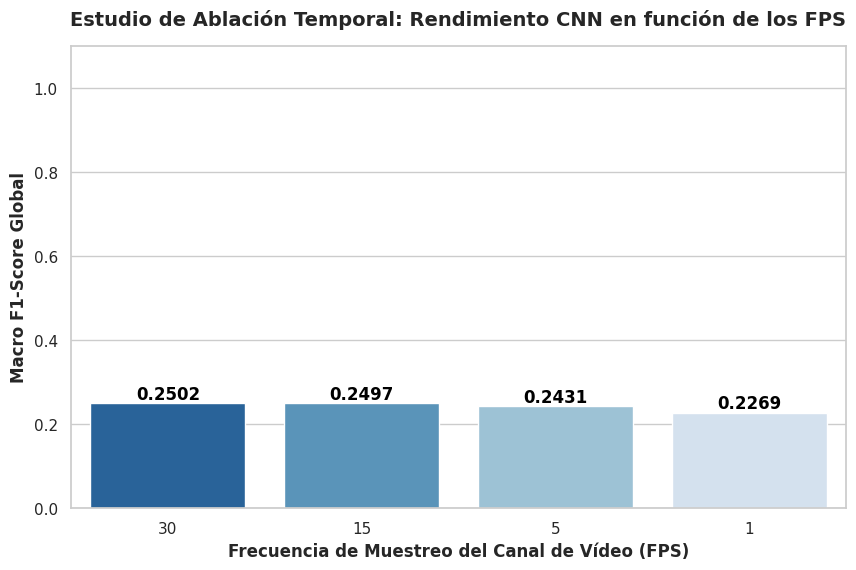

In [4]:
# Aislamiento matemático de la respuesta óptima por cada tasa de refresco independiente
mejores_por_fps = df_resultados.loc[df_resultados.groupby('FPS')['Macro_F1'].idxmax()].sort_values('FPS', ascending=False)

print("\n" + "="*60)
print("COMPROMISO COMPUTACIONAL EN FUNCIÓN DE LA FRECUENCIA DE MUESTREO")
print("="*60)
display(mejores_por_fps)

# Visualización formal del análisis de ablación para la memoria del TFG
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
grafico = sns.barplot(x='FPS', y='Macro_F1', data=mejores_por_fps, palette='Blues_r', order=[30, 15, 5, 1])

for index, row in enumerate(mejores_por_fps.itertuples()):
    grafico.text(index, row.Macro_F1 + 0.01, f"{row.Macro_F1:.4f}", color='black', ha="center", fontweight='bold')

plt.title('Estudio de Ablación Temporal: Rendimiento CNN en función de los FPS', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frecuencia de Muestreo del Canal de Vídeo (FPS)', fontsize=12, fontweight='bold')
plt.ylabel('Macro F1-Score Global', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.show()

## 5. EVALUACIÓN DE MÉTRICAS FINALES (BASELINE TINYML A 5 FPS)

DIAGNÓSTICO MATRICIAL PARA ENTORNO EMBEBIDO TINYML (5 FPS)
Configuración Óptima: Ventana PERCLOS = 60s | Umbral P_{th} = 0.1 | Racha Bostezo = 1.5s


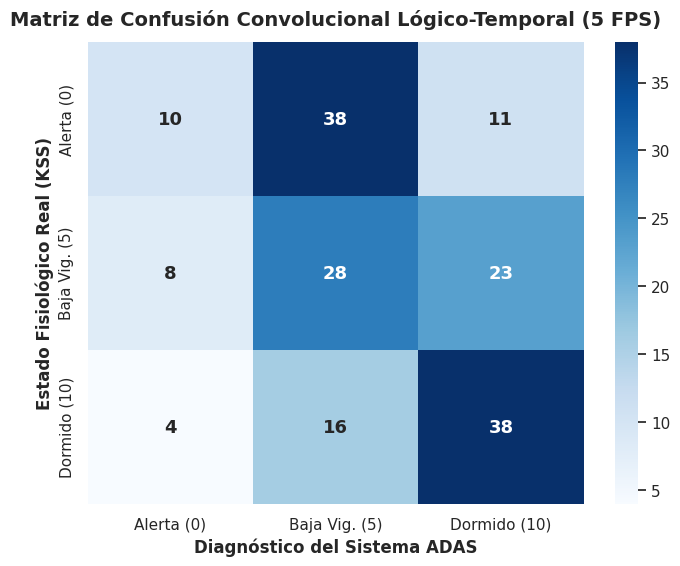


REPORTE CLÍNICO FINAL DE CLASIFICACIÓN CONVOLUCIONAL (5 FPS)
               precision    recall  f1-score   support

   Alerta (0)       0.42      0.17      0.24        59
Baja Vig. (5)       0.34      0.47      0.39        59
 Dormido (10)       0.52      0.66      0.58        58

    micro avg       0.42      0.43      0.43       176
    macro avg       0.42      0.43      0.41       176
 weighted avg       0.42      0.43      0.40       176



In [5]:
# Extracción automática del rendimiento correspondiente a la cota TinyML (5 FPS)
try:
    config_optima_5fps = mejores_por_fps[mejores_por_fps['FPS'] == 5].iloc[0]
except IndexError:
    config_optima_5fps = mejores_por_fps.iloc[0]

opt_fps = int(config_optima_5fps['FPS'])
opt_w = int(config_optima_5fps['W_Perclos'])
opt_p = config_optima_5fps['P_th']
opt_b = config_optima_5fps['B_sec']

print("="*70)
print(f"DIAGNÓSTICO MATRICIAL PARA ENTORNO EMBEBIDO TINYML ({opt_fps} FPS)")
print(f"Configuración Óptima: Ventana PERCLOS = {opt_w}s | Umbral P_{{th}} = {opt_p} | Racha Bostezo = {opt_b}s")
print("="*70)

df_opt_fps = datos_dict[opt_fps]
y_true_opt, y_pred_opt = evaluar_dataset_completo(df_opt_fps, opt_fps, opt_w, opt_p, opt_b)

# Representación de la Matriz de Confusión Empírica
cm = confusion_matrix(y_true_opt, y_pred_opt, labels=[0, 5, 10])
etiquetas_clinicas = ['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas_clinicas,
            yticklabels=etiquetas_clinicas,
            annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Matriz de Confusión Convolucional Lógico-Temporal ({opt_fps} FPS)', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Estado Fisiológico Real (KSS)', fontsize=12, fontweight='bold')
plt.xlabel('Diagnóstico del Sistema ADAS', fontsize=12, fontweight='bold')
plt.show()

# Reporte formal de métricas estadísticas de la fase experimental
print("\n" + "="*55)
print(f"REPORTE CLÍNICO FINAL DE CLASIFICACIÓN CONVOLUCIONAL ({opt_fps} FPS)")
print("="*55)
print(classification_report(y_true_opt, y_pred_opt, labels=[0, 5, 10], target_names=etiquetas_clinicas))

## 6. AUDITORÍA DE CASOS CRÍTICOS Y FALLOS DE SEGURIDAD FUNCTIONAL

In [6]:
# Reconstrucción del vector tabular para aislar y trazar fallos específicos
videos_audit = df_opt_fps['video'].unique()
df_optimo = pd.DataFrame({
    'video': videos_audit,
    'real': y_true_opt,
    'pred': y_pred_opt
})

aciertos = df_optimo[df_optimo['real'] == df_optimo['pred']]
fallos = df_optimo[df_optimo['real'] != df_optimo['pred']]

print("\n" + "="*60)
print("AUDITORÍA DE CASOS CRÍTICOS")
print("="*60)

print("\n CASOS DE ÉXITO EN EL DIAGNÓSTICO PREVENTIVO:")
for clase in [0, 5, 10]:
    ejemplo = aciertos[aciertos['real'] == clase].head(1)
    if not ejemplo.empty:
        vid = ejemplo.iloc[0]['video']
        print(f"    - Estado KSS {clase}: El vídeo '{vid}' se clasificó correctamente.")

print("\n ANÁLISIS DE ERRORES DE TIPO II (FALSOS NEGATIVOS CRÍTICOS):")
falsos_negativos = fallos[(fallos['real'] == 10) & (fallos['pred'] == 0)]
if not falsos_negativos.empty:
    print(f"    -  Omisión de microsueño severo (10 clasificado como alerta 0):")
    print(f"      Vídeo asociado al fallo de seguridad -> {falsos_negativos.iloc[0]['video']}")
else:
    # Verificación secundaria en estados de transición
    fn_transicion = fallos[(fallos['real'] == 5) & (fallos['pred'] == 0)]
    if not fn_transicion.empty:
        print(f"    -  Omisión de fatiga incipiente (5 clasificado como alerta 0):")
        print(f"      Vídeo asociado al retraso preventivo -> {fn_transicion.iloc[0]['video']}")
    else:
        print("    -  No se registraron omisiones clínicas de peligro en el subconjunto evaluado.")

print("\n[-] ANÁLISIS DE ERRORES DE TIPO I (FALSAS ALARMAS INTRUSIVAS):")
falsos_positivos_extremos = fallos[(fallos['real'] == 0) & (fallos['pred'] == 10)]
if not falsos_positivos_extremos.empty:
    print(f"    - Conductor en vigilia (0) diagnosticado como microsueño (10):")
    print(f"      Vídeo causante del rechazo ergonómico -> {falsos_positivos_extremos.iloc[0]['video']}")
else:
    print("    -  Inexistencia de falsos positivos extremos entre alerta plena y somnolencia severa.")


AUDITORÍA FORENSE DE CASOS CRÍTICOS (SEGURIDAD FUNCIONAL ADAS)

[+] CASOS DE ÉXITO EN EL DIAGNÓSTICO PREVENTIVO:
    - Estado KSS 0: El vídeo '10_0.MOV' se clasificó correctamente.
    - Estado KSS 5: El vídeo '04_5.mp4' se clasificó correctamente.
    - Estado KSS 10: El vídeo '02_10.MOV' se clasificó correctamente.

[-] ANÁLISIS DE ERRORES DE TIPO II (FALSOS NEGATIVOS CRÍTICOS):
    - [CRÍTICO] Omisión de microsueño severo (10 clasificado como alerta 0):
      Vídeo asociado al fallo de seguridad -> 11_10.mp4

[-] ANÁLISIS DE ERRORES DE TIPO I (FALSAS ALARMAS INTRUSIVAS):
    - [ALERTA FALSA] Conductor en vigilia (0) diagnosticado como microsueño (10):
      Vídeo causante del rechazo ergonómico -> 08_0.mp4


## 6. AUDITORÍA DE CASOS CRÍTICOS (Falsos Negativos y Falsos Positivos)

In [7]:
# Reconstruir el dataframe de resultados óptimos para aislar el identificador de los vídeos
videos_audit = df_opt_fps['video'].unique()
df_optimo = pd.DataFrame({
    'video': videos_audit,
    'real': y_true_opt,
    'pred': y_pred_opt
})

aciertos = df_optimo[df_optimo['real'] == df_optimo['pred']]
fallos = df_optimo[df_optimo['real'] != df_optimo['pred']]

print("\n" + "="*50)
print("AUDITORÍA DE CASOS (MEJORES Y PEORES)")
print("="*50)

print("\nEJEMPLOS DE ACIERTOS (Casos de Éxito):")
for clase in [0, 5, 10]:
    ejemplo = aciertos[aciertos['real'] == clase].head(1)
    if not ejemplo.empty:
        vid = ejemplo.iloc[0]['video']
        print(f"  - El vídeo '{vid}' era Clase {clase} y se predijo correctamente como {clase}.")

print("\nEJEMPLOS DE FALLOS (El problema de la Clase 5):")
falsos_negativos = fallos[(fallos['real'] == 5) & (fallos['pred'] == 0)]
if not falsos_negativos.empty:
    print(f"  - Peligro: El conductor estaba en Baja Vigilancia (5), pero la red CNN dijo Alerta (0):")
    print(f"    Ejemplo -> Vídeo: {falsos_negativos.iloc[0]['video']}")

falsos_positivos_extremos = fallos[(fallos['real'] == 0) & (fallos['pred'] == 10)]
if not falsos_positivos_extremos.empty:
    print(f"\n  - Alerta Intrusiva: El conductor estaba en Alerta (0), pero la red CNN predijo Microsueño (10):")
    print(f"    Ejemplo -> Vídeo: {falsos_positivos_extremos.iloc[0]['video']}")
else:
    print("\n  - Éxito Excepcional: La red no registró falsos positivos extremos (0 diagnosticado como 10).")


AUDITORÍA DE CASOS (MEJORES Y PEORES)

EJEMPLOS DE ACIERTOS (Casos de Éxito):
  - El vídeo '10_0.MOV' era Clase 0 y se predijo correctamente como 0.
  - El vídeo '04_5.mp4' era Clase 5 y se predijo correctamente como 5.
  - El vídeo '02_10.MOV' era Clase 10 y se predijo correctamente como 10.

EJEMPLOS DE FALLOS (El problema de la Clase 5):
  - Peligro: El conductor estaba en Baja Vigilancia (5), pero la red CNN dijo Alerta (0):
    Ejemplo -> Vídeo: 17_5.mp4

  - Alerta Intrusiva: El conductor estaba en Alerta (0), pero la red CNN predijo Microsueño (10):
    Ejemplo -> Vídeo: 08_0.mp4
